<center><h1>Методы Монте-Карло и машинное обучение</h1></center>

# Лекция-семинар 7

7. **Оптимизация гиперпараметров с использованием Монте-Карло**
    - Применение методов Монте-Карло для стохастической оптимизации гиперпараметров, включая имитацию отжига и байесовскую оптимизацию
    - Акцент на настройке моделей машинного обучения для повышения их производительности

## Оптимизация гиперпараметров с использованием методов Монте-Карло

### Введение в оптимизацию гиперпараметров

### Определение гиперпараметров и их влияние на производительность моделей

Гиперпараметры - параметры модели машинного обучения, которые не обучаются на данных, а устанавливаются заранее. Они определяют, как модель будет обучаться и насколько хорошо она сможет обобщать данные

Примеры гиперпараметров
- Количество слоев и нейронов в нейросети
- Коэффициент обучения (`learning rate`)
- Размер мини-батча
- Тип и сила регуляризации (`L1, L2`)
- Гиперпараметры оптимизатора (например, momentum, beta в `Adam`)

Настройка гиперпараметров может существенно повлиять на точность модели, ее способность к обобщению и скорость сходимости

### Классические методы оптимизации гиперпараметров

#### Grid Search (поиск по сетке)

Метод Grid Search перебирает все возможные комбинации значений гиперпараметров в заданном диапазоне. Это простой, но вычислительно затратный метод

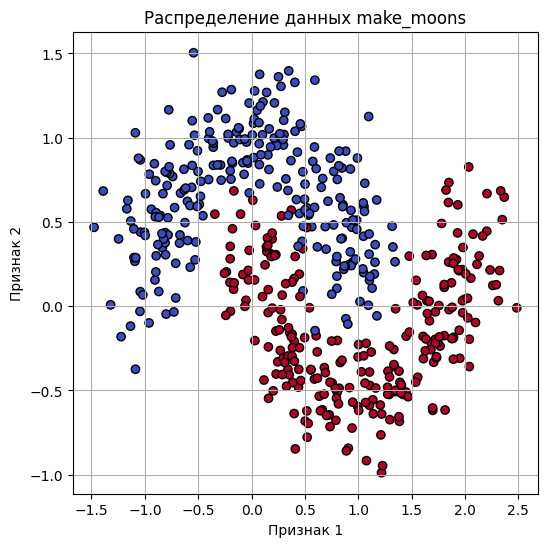

Лучшие параметры: {'max_depth': None, 'n_estimators': 10}
Точность до оптимизации: 0.9800
Точность после оптимизации: 0.9933


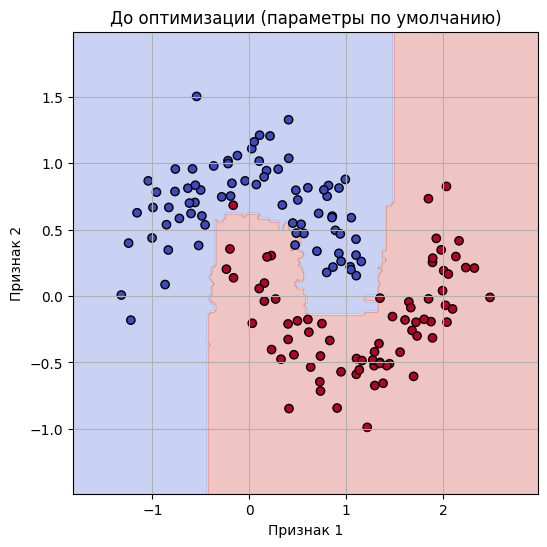

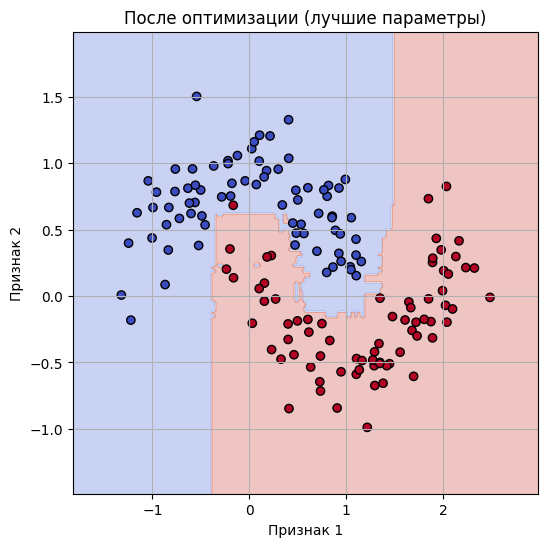

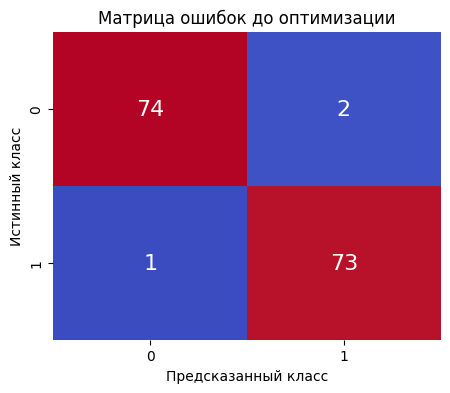

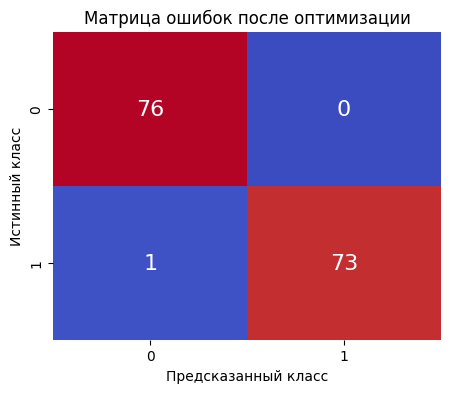

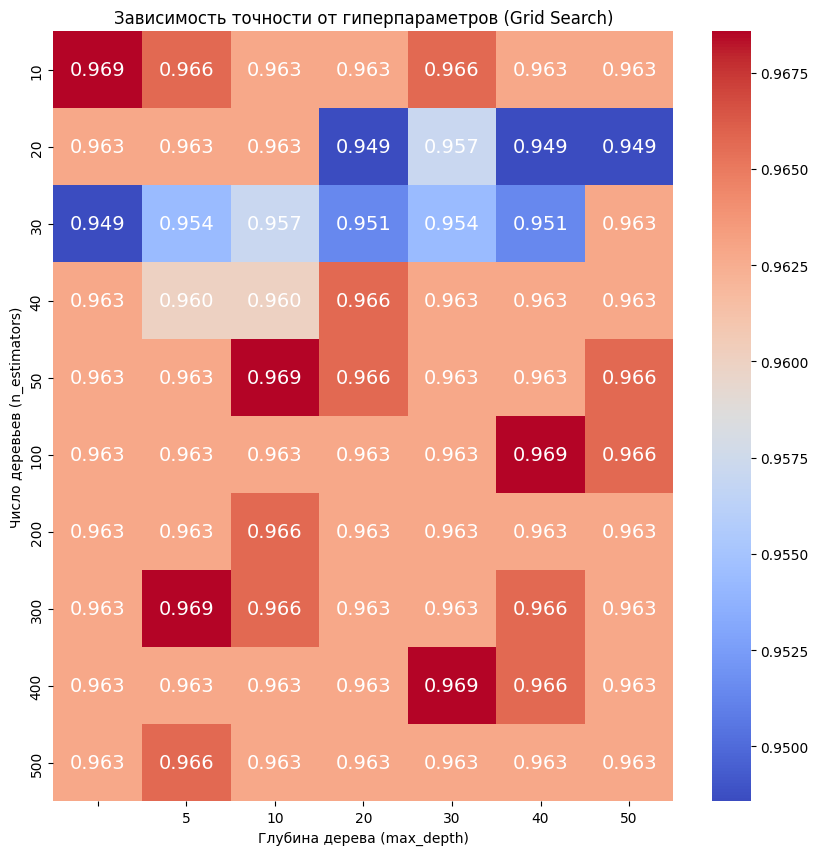

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Генерация данных
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Визуализация данных
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Распределение данных make_moons")
plt.grid(True)
plt.show()

# Оптимизация гиперпараметров с Grid Search
param_grid = {
    "n_estimators": [10, 20, 30, 40, 50, 100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 20, 30, 40, 50]
}

model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Вывод лучших параметров
best_params = grid_search.best_params_
print("Лучшие параметры:", best_params)

# Обучение модели до оптимизации (без подбора гиперпараметров)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

# Обучение модели после оптимизации
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Оценка точности
accuracy_default = accuracy_score(y_test, y_pred_default)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Точность до оптимизации: {accuracy_default:.4f}")
print(f"Точность после оптимизации: {accuracy_best:.4f}")

# Функция для визуализации границы решений
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Визуализация границы решений до и после оптимизации
plot_decision_boundary(rf_default, X_test, y_test, "До оптимизации (параметры по умолчанию)")
plot_decision_boundary(best_model, X_test, y_test, "После оптимизации (лучшие параметры)")

# Функция для отображения матрицы ошибок с улучшенным стилем
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, annot_kws={"size": 16, "color": "white"})
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

# Матрицы ошибок до и после оптимизации
plot_confusion_matrix(y_test, y_pred_default, "Матрица ошибок до оптимизации")
plot_confusion_matrix(y_test, y_pred_best, "Матрица ошибок после оптимизации")

# Визуализация зависимости точности от гиперпараметров
results = grid_search.cv_results_
scores = np.array(results["mean_test_score"]).reshape(len(param_grid["n_estimators"]), len(param_grid["max_depth"]))

plt.figure(figsize=(10, 10))
sns.heatmap(scores, annot=True, fmt=".3f", xticklabels=param_grid["max_depth"], yticklabels=param_grid["n_estimators"], cmap="coolwarm", annot_kws={"size": 14, "color": "white"})
plt.xlabel("Глубина дерева (max_depth)")
plt.ylabel("Число деревьев (n_estimators)")
plt.title("Зависимость точности от гиперпараметров (Grid Search)")
plt.show()

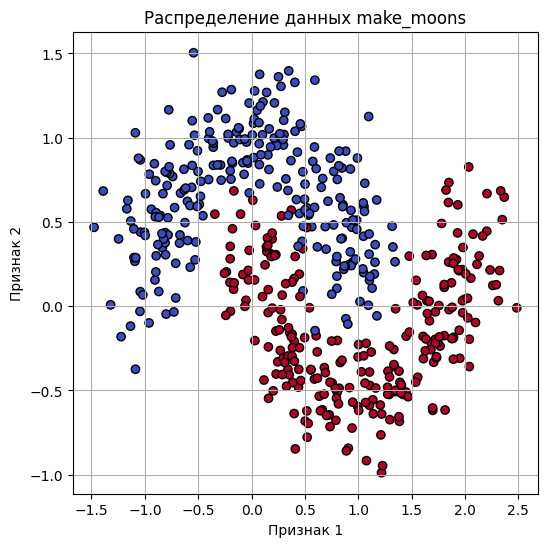

Лучшие параметры: {'max_depth': 40, 'n_estimators': 170}
Точность до оптимизации: 0.9800
Точность после оптимизации: 0.9867


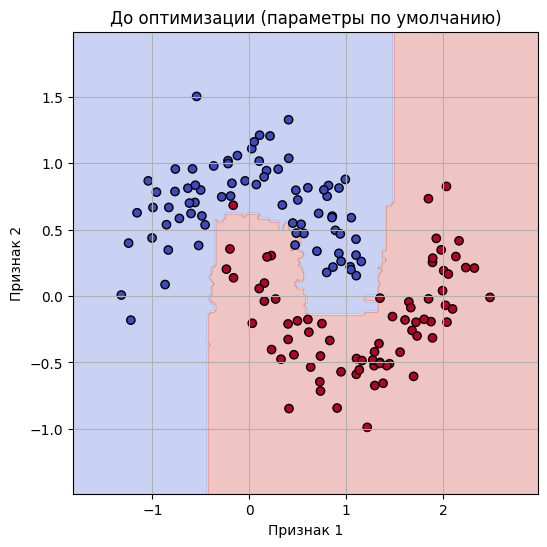

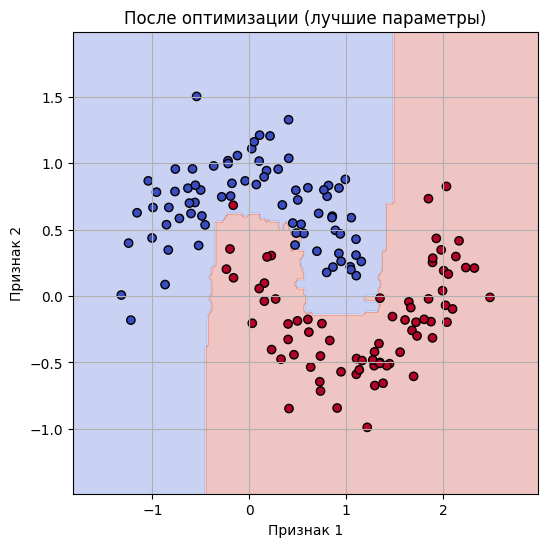

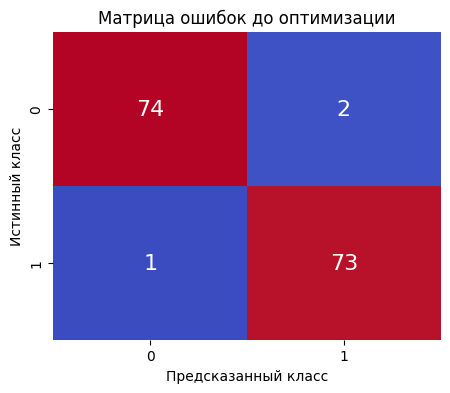

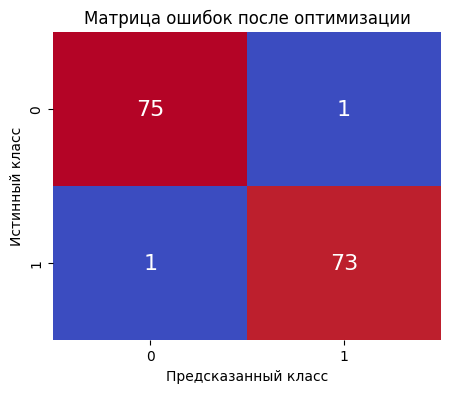

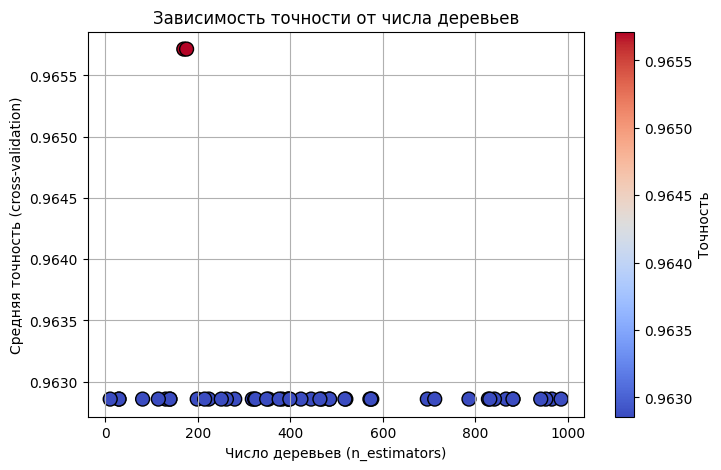

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Генерация данных
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Визуализация данных
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Распределение данных make_moons")
plt.grid(True)
plt.show()

# Оптимизация гиперпараметров с Randomized Search
param_dist = {
    "n_estimators": randint(10, 1000),
    "max_depth": [None, 10, 20, 30, 40, 50, 100, 200]
}

model = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=50, cv=5, scoring="accuracy", n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# Вывод лучших параметров
best_params = random_search.best_params_
print("Лучшие параметры:", best_params)

# Обучение модели до оптимизации (без подбора гиперпараметров)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

# Обучение модели после оптимизации
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Оценка точности
accuracy_default = accuracy_score(y_test, y_pred_default)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Точность до оптимизации: {accuracy_default:.4f}")
print(f"Точность после оптимизации: {accuracy_best:.4f}")

# Функция для визуализации границы решений
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Визуализация границы решений до и после оптимизации
plot_decision_boundary(rf_default, X_test, y_test, "До оптимизации (параметры по умолчанию)")
plot_decision_boundary(best_model, X_test, y_test, "После оптимизации (лучшие параметры)")

# Функция для отображения матрицы ошибок с улучшенным стилем
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, annot_kws={"size": 16, "color": "white"})
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

# Матрицы ошибок до и после оптимизации
plot_confusion_matrix(y_test, y_pred_default, "Матрица ошибок до оптимизации")
plot_confusion_matrix(y_test, y_pred_best, "Матрица ошибок после оптимизации")

# Визуализация зависимости точности от числа деревьев
results = random_search.cv_results_
n_estimators_values = [param["n_estimators"] for param in random_search.cv_results_["params"]]
scores = results["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.scatter(n_estimators_values, scores, c=scores, cmap="coolwarm", edgecolors="k", s=100)
plt.colorbar(label="Точность")
plt.xlabel("Число деревьев (n_estimators)")
plt.ylabel("Средняя точность (cross-validation)")
plt.title("Зависимость точности от числа деревьев")
plt.grid(True)
plt.show()

### Проблемы перебора гиперпараметров в высокоразмерных пространствах

1. `Комбинаторный взрыв` - количество возможных комбинаций растет экспоненциально с увеличением числа гиперпараметров
2. `Неэффективность на сложных задачах`
    - `Grid Search` тратит вычислительные ресурсы на перебор всех комбинаций, включая неэффективные области пространства параметров
    - `Random Search` может случайно пропустить важные области пространства параметров
3. `Высокая вычислительная сложность` - для нейросетей и сложных моделей требуется много итераций для поиска оптимальных параметров. Традиционные методы неэффективны для глубоких моделей, требующих долгого обучения

## Стохастические методы оптимизации гиперпараметров

### Имитация отжига (Simulated Annealing)

Метод оптимизации, вдохновленный процессами термодинамического отжига. Он особенно полезен, когда поверхность потерь сложна, а градиентные методы неэффективны

#### Основные идеи
- Начинаем с **случайного набора гиперпараметров**
- На каждом шаге пробуем **небольшое случайное изменение**
- Если новое значение **улучшает результат**, принимаем его
- Если нет - иногда тоже принимаем, **чтобы избежать локальных минимумов** (с вероятностью, зависящей от `температуры`)

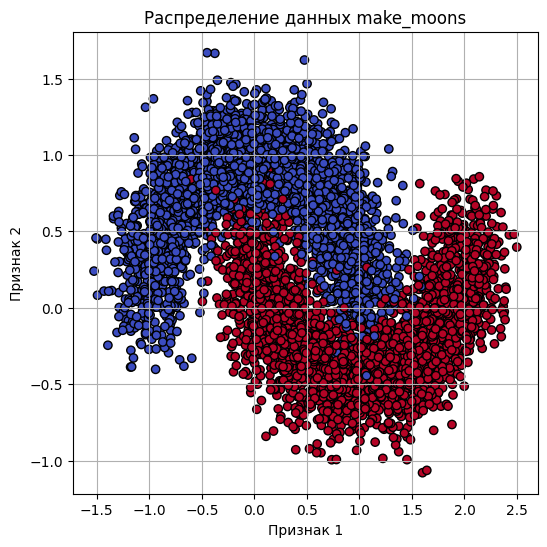

Лучшие параметры (имитация отжига): {'n_estimators': 117, 'max_depth': 10}
Лучшая точность: 0.9707
Точность до оптимизации: 0.9680
Точность после оптимизации: 0.9693


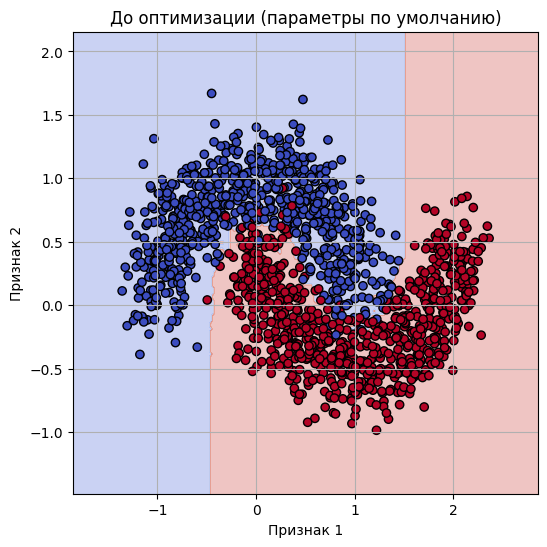

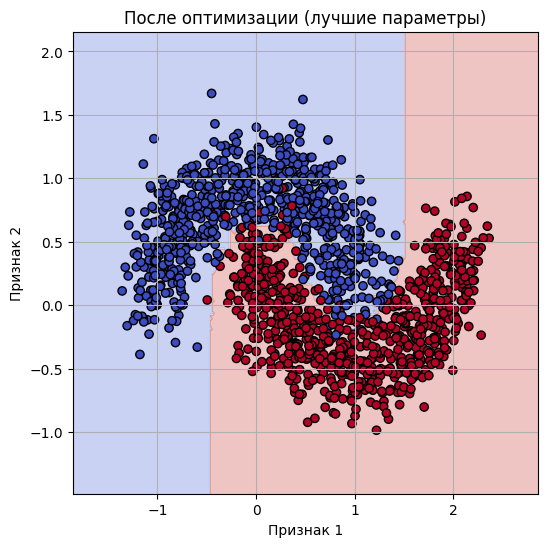

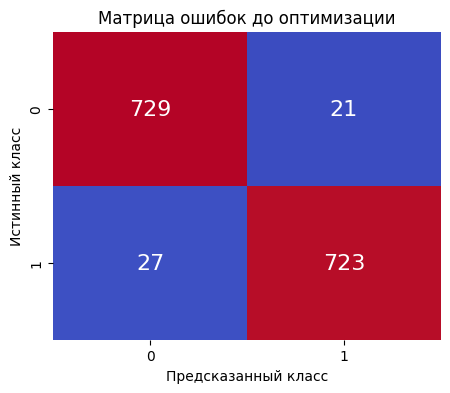

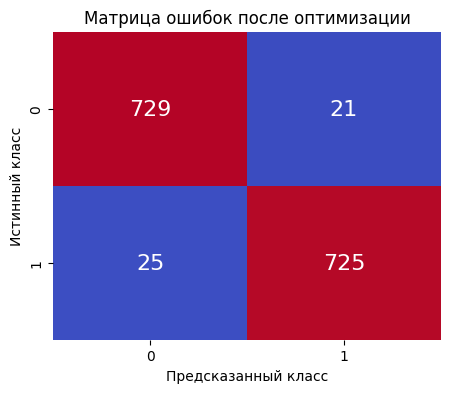

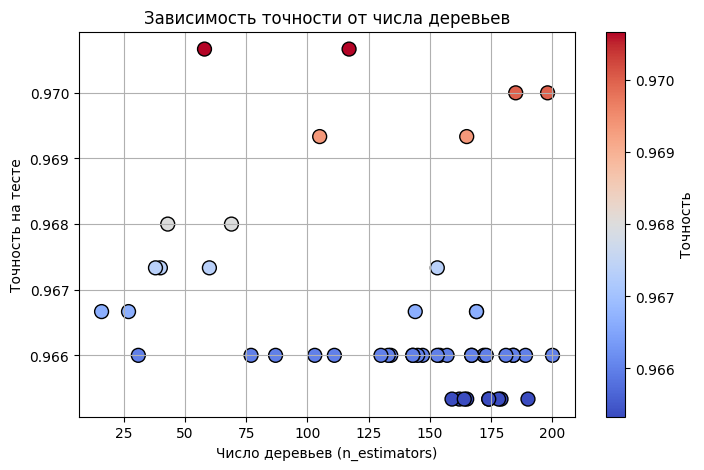

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Генерация данных
X, y = make_moons(n_samples=5000, noise=0.2, random_state=2025)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Визуализация данных
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Распределение данных make_moons")
plt.grid(True)
plt.show()

# Функция оценки точности модели
def evaluate(params):
    model = RandomForestClassifier(n_estimators=params["n_estimators"], max_depth=params["max_depth"], random_state=2025)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

# Функция имитации отжига для оптимизации гиперпараметров
def simulated_annealing(max_iter=50, initial_temp=1.0, cooling_rate=0.95):
    # Начальное случайное значение параметров
    current_params = {"n_estimators": np.random.randint(10, 1000), "max_depth": np.random.choice([None, 10, 20, 30, 40])}
    current_score = evaluate(current_params)

    best_params, best_score = current_params, current_score
    temp = initial_temp

    scores, n_estimators_values = [], []

    for _ in range(max_iter):
        # Генерация нового набора параметров
        new_params = {
            "n_estimators": np.clip(current_params["n_estimators"] + np.random.randint(-20, 20), 10, 200),
            "max_depth": np.random.choice([None, 10, 20, 30, 40])
        }
        
        new_score = evaluate(new_params)

        # Запоминаем результаты для визуализации
        scores.append(new_score)
        n_estimators_values.append(new_params["n_estimators"])

        # Критерий Метрополиса для принятия нового решения
        if new_score > current_score or np.exp((new_score - current_score) / temp) > np.random.rand():
            current_params, current_score = new_params, new_score

        # Обновляем лучшее решение
        if current_score > best_score:
            best_params, best_score = current_params, current_score

        # Охлаждение температуры
        temp *= cooling_rate

    return best_params, best_score, scores, n_estimators_values

# Запуск оптимизации
best_params, best_score, scores, n_estimators_values = simulated_annealing()

print("Лучшие параметры (имитация отжига):", best_params)
print(f"Лучшая точность: {best_score:.4f}")

# Обучение модели до оптимизации (по умолчанию)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

# Обучение модели после оптимизации
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Оценка точности
accuracy_default = accuracy_score(y_test, y_pred_default)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Точность до оптимизации: {accuracy_default:.4f}")
print(f"Точность после оптимизации: {accuracy_best:.4f}")

# Функция для визуализации границы решений
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Визуализация границы решений до и после оптимизации
plot_decision_boundary(rf_default, X_test, y_test, "До оптимизации (параметры по умолчанию)")
plot_decision_boundary(best_model, X_test, y_test, "После оптимизации (лучшие параметры)")

# Функция для отображения матрицы ошибок
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, annot_kws={"size": 16, "color": "white"})
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

# Матрицы ошибок до и после оптимизации
plot_confusion_matrix(y_test, y_pred_default, "Матрица ошибок до оптимизации")
plot_confusion_matrix(y_test, y_pred_best, "Матрица ошибок после оптимизации")

# Визуализация зависимости точности от числа деревьев
plt.figure(figsize=(8, 5))
plt.scatter(n_estimators_values, scores, c=scores, cmap="coolwarm", edgecolors="k", s=100)
plt.colorbar(label="Точность")
plt.xlabel("Число деревьев (n_estimators)")
plt.ylabel("Точность на тесте")
plt.title("Зависимость точности от числа деревьев")
plt.grid(True)
plt.show()

## Байесовская оптимизация (Bayesian Optimization)

Метод, который строит статистическую модель функции потерь, а затем выбирает наиболее перспективные точки для проверки

### Основные идеи

- Используются гауссовские процессы или деревья Парзена для моделирования функции ошибок
- Выбираются новые точки на основе баланса исследования и эксплуатации
- Этот метод особенно хорош, когда оценка одного набора параметров дорогая

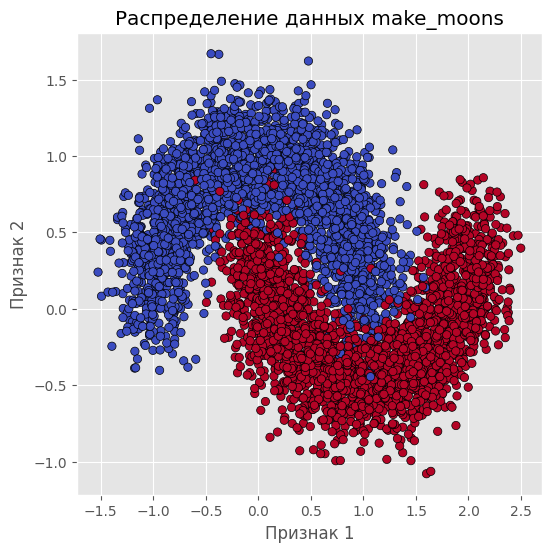

[I 2025-03-04 11:26:33,271] A new study created in memory with name: no-name-e26c6796-6797-4295-a180-5850ad0cd233
[I 2025-03-04 11:26:35,400] Trial 3 finished with value: 0.9717142857142858 and parameters: {'n_estimators': 51, 'max_depth': None}. Best is trial 3 with value: 0.9717142857142858.
[I 2025-03-04 11:26:35,588] Trial 2 finished with value: 0.9711428571428572 and parameters: {'n_estimators': 193, 'max_depth': 10}. Best is trial 3 with value: 0.9717142857142858.
[I 2025-03-04 11:26:36,371] Trial 7 finished with value: 0.9720000000000001 and parameters: {'n_estimators': 89, 'max_depth': 10}. Best is trial 7 with value: 0.9720000000000001.
[I 2025-03-04 11:26:36,526] Trial 1 finished with value: 0.9714285714285713 and parameters: {'n_estimators': 295, 'max_depth': 50}. Best is trial 7 with value: 0.9720000000000001.
[I 2025-03-04 11:26:36,561] Trial 4 finished with value: 0.9714285714285713 and parameters: {'n_estimators': 227, 'max_depth': 30}. Best is trial 7 with value: 0.9720

Лучшие параметры (Optuna): {'n_estimators': 50, 'max_depth': 10}
Лучший accuracy на кросс-валидации: 0.9723
Точность до оптимизации: 0.9680
Точность после оптимизации: 0.9707


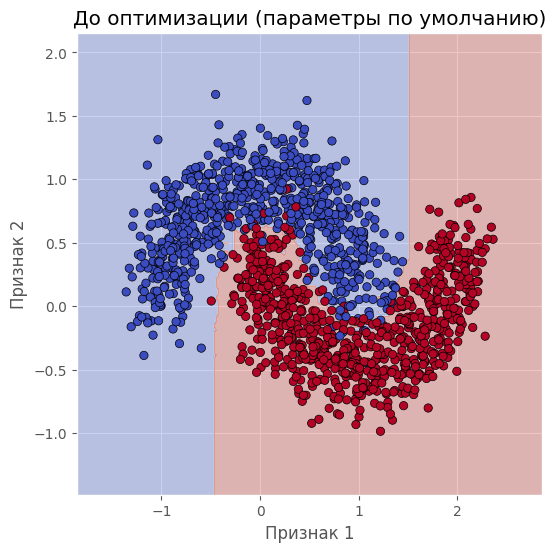

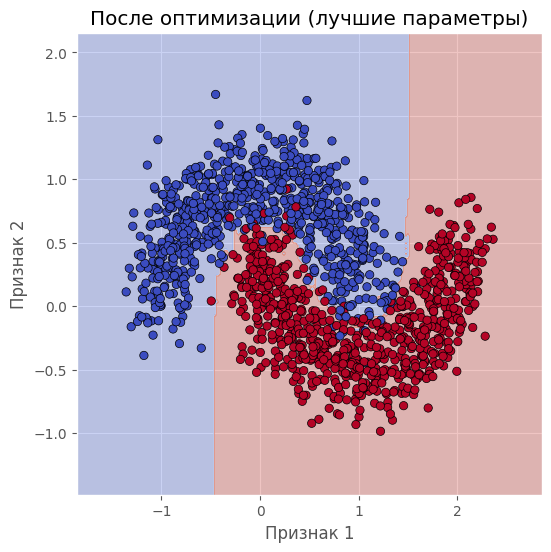

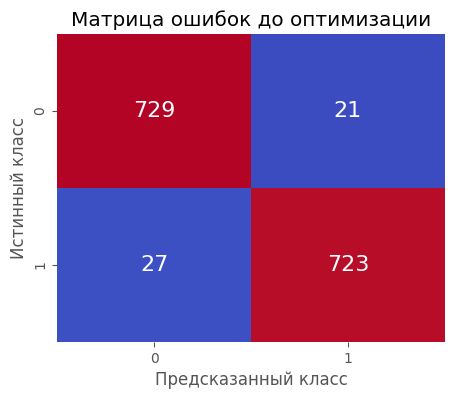

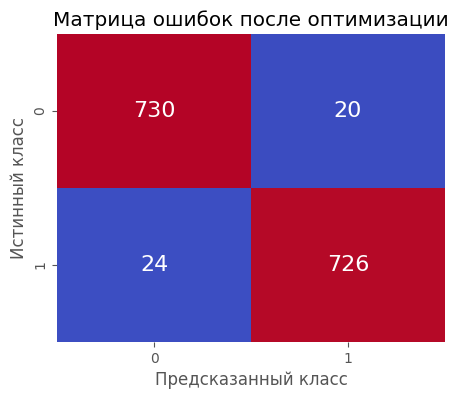

/var/folders/gw/w3k5kxtx0s3_nqdqw94zr8yh0000gn/T/ipykernel_72930/123567903.py:103: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


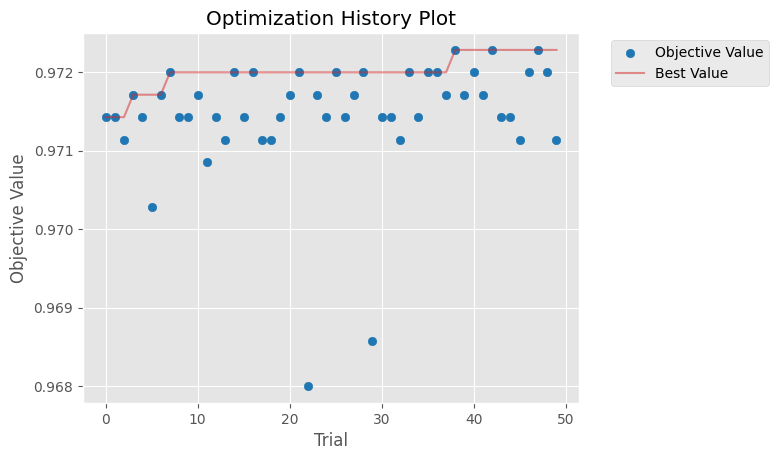

/var/folders/gw/w3k5kxtx0s3_nqdqw94zr8yh0000gn/T/ipykernel_72930/123567903.py:106: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


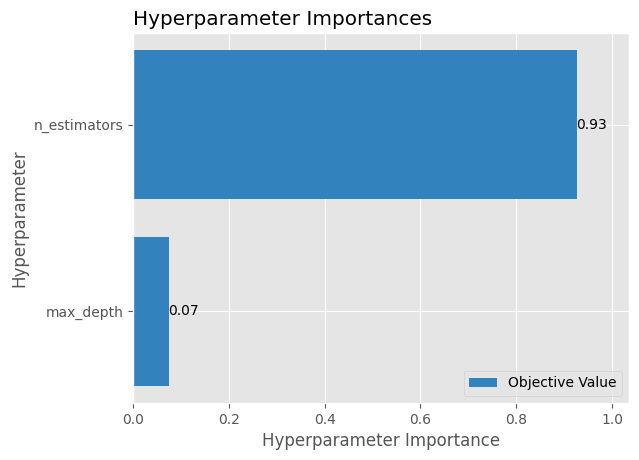

In [18]:
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*plot_param_importances.*")

# Генерация данных
X, y = make_moons(n_samples=5000, noise=0.2, random_state=2025)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Визуализация данных
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.title("Распределение данных make_moons")
plt.grid(True)
plt.show()

# Функция для Optuna
def objective(trial):
    """Оптимизируем гиперпараметры RandomForestClassifier."""
    n_estimators = trial.suggest_int("n_estimators", 10, 300)
    max_depth = trial.suggest_categorical("max_depth", [None, 10, 20, 30, 40, 50])
    
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=2025, n_jobs=-1)
    accuracy = np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1))
    
    return accuracy  # Оптимизируем точность

# Запуск байесовской оптимизации через Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, n_jobs=-1)  # 50 итераций

# Вывод лучших параметров
best_params = study.best_params
print("Лучшие параметры (Optuna):", best_params)
print(f"Лучший accuracy на кросс-валидации: {study.best_value:.4f}")

# Обучение модели до оптимизации (по умолчанию)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

# Обучение модели после оптимизации
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Оценка точности
accuracy_default = accuracy_score(y_test, y_pred_default)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Точность до оптимизации: {accuracy_default:.4f}")
print(f"Точность после оптимизации: {accuracy_best:.4f}")

# Функция для визуализации границы решений
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Визуализация границы решений до и после оптимизации
plot_decision_boundary(rf_default, X_test, y_test, "До оптимизации (параметры по умолчанию)")
plot_decision_boundary(best_model, X_test, y_test, "После оптимизации (лучшие параметры)")

# Функция для отображения матрицы ошибок
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, annot_kws={"size": 16, "color": "white"})
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

# Матрицы ошибок до и после оптимизации
plot_confusion_matrix(y_test, y_pred_default, "Матрица ошибок до оптимизации")
plot_confusion_matrix(y_test, y_pred_best, "Матрица ошибок после оптимизации")

# Визуализация процесса оптимизации Optuna
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

In [22]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons

# Генерация данных
X, y = make_moons(n_samples=5000, noise=0.2, random_state=2025)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# Определение стека моделей
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=2025)),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2025))
]

# Логистическая регрессия как мета-learner
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())

# Определение целевой функции для Optuna
def objective(trial):
    # Применяем Optuna для настройки гиперпараметров
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
    rf_max_depth = trial.suggest_int('rf_max_depth', 5, 20)
    gb_n_estimators = trial.suggest_int('gb_n_estimators', 50, 200)
    gb_learning_rate = trial.suggest_float('gb_learning_rate', 1e-3, 1e-1, log=True)

    # Обновляем параметры для модели
    base_learners = [
        ('rf', RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, random_state=2025)),
        ('gb', GradientBoostingClassifier(n_estimators=gb_n_estimators, learning_rate=gb_learning_rate, random_state=2025))
    ]
    
    stacking_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())
    
    # Обучаем модель
    stacking_model.fit(X_train, y_train)
    
    # Предсказание и вычисление точности
    y_pred = stacking_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    return accuracy

# Запуск Optuna для подбора гиперпараметров
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Вывод лучших параметров и точности
print("Лучшие параметры:", study.best_params)
print("Лучшая точность:", study.best_value)

[I 2025-03-04 11:50:55,827] A new study created in memory with name: no-name-d198b181-91f7-41f1-8874-0356272e3b10
[I 2025-03-04 11:51:00,107] Trial 0 finished with value: 0.968 and parameters: {'rf_n_estimators': 107, 'rf_max_depth': 16, 'gb_n_estimators': 114, 'gb_learning_rate': 0.012329917557899387}. Best is trial 0 with value: 0.968.
[I 2025-03-04 11:51:04,359] Trial 1 finished with value: 0.9706666666666667 and parameters: {'rf_n_estimators': 66, 'rf_max_depth': 10, 'gb_n_estimators': 129, 'gb_learning_rate': 0.03467547182948575}. Best is trial 1 with value: 0.9706666666666667.
[I 2025-03-04 11:51:07,655] Trial 2 finished with value: 0.9693333333333334 and parameters: {'rf_n_estimators': 76, 'rf_max_depth': 9, 'gb_n_estimators': 62, 'gb_learning_rate': 0.010846498828140571}. Best is trial 1 with value: 0.9706666666666667.
[I 2025-03-04 11:51:14,805] Trial 3 finished with value: 0.9666666666666667 and parameters: {'rf_n_estimators': 181, 'rf_max_depth': 16, 'gb_n_estimators': 151, 

Лучшие параметры: {'rf_n_estimators': 122, 'rf_max_depth': 8, 'gb_n_estimators': 76, 'gb_learning_rate': 0.002176038288754803}
Лучшая точность: 0.9746666666666667


## Разбор современного примера

#### Метод объединения результатов аудио- и видео моделей распознавания речи

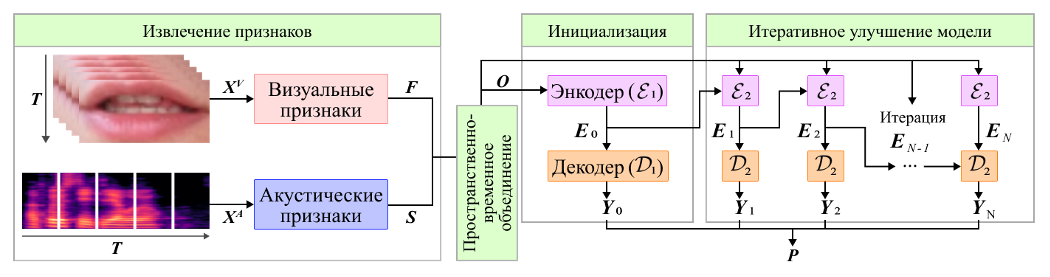

Данный пример показывает, как метод аудиовизуального распознавания речи, который использует оптимизацию гиперпараметров с применением методов Монте-Карло может быть популярным решением в области бимодального распознавания речи.

В основе предложенного подхода лежат регулируемые трансформеры (`regulated transformers`), и метод интегрирует данные из аудио- и видеомоделей для улучшения точности распознавания.

В соответствии с современными мировыми тенденциями, предложенный метод использует архитектуру трансформера, включающую следующие четыре ключевых модуля

1. **Извлечение признаков**: этап, на котором из аудио- и видеопотока извлекаются важные признаки для дальнейшей обработки. Применение методов оптимизации гиперпараметров позволяет автоматически настраивать параметры извлечения признаков, что способствует улучшению общей производительности модели

2. **Пространственно-временное объединение**: на этом этапе данные из разных источников (аудио и видео) объединяются в единую пространственно-временную структуру, что помогает учитывать как временные зависимости, так и пространственные особенности (например, положение губ при произнесении звуков)

3. **Инициализация модели**: важно выбрать оптимальные начальные параметры модели, что может значительно ускорить процесс обучения и улучшить ее точность. Для этого используется метод Монте-Карло для случайной инициализации гиперпараметров, что позволяет исследовать различные начальные условия

4. **Итеративное улучшение модели**: итеративное улучшение модели включает в себя постепенную настройку гиперпараметров на основе результатов каждого шага. Использование методов Монте-Карло, таких, как имитация отжига и байесовская оптимизация, помогает найти оптимальные значения гиперпараметров для повышения точности распознавания

### Формирование представления функции отображения и обработка входных данных

Основой метода является построение представления функции отображения

$$
f: X^A, X^V \to P
$$

для каждой аудиовизуальной записи, где $X^A$ и $X^V$ соответствуют аудио- и видео-входным сигналам соответственно, а $P$ - это предсказание класса

Аудио и видео сигналы представлены в виде последовательностей

$$
X^A = \{x_t^A\}_{t=1}^{T}, \quad X^V = \{x_t^V\}_{t=1}^{T}
$$

где $T$ - количество временных шагов, соответствующих спектрограммам аудио или кадрам видео

#### Извлечение признаков

Для обработки входных данных используются два отдельных экстрактора признаков

- **Визуальный экстрактор** преобразует $X^V$ в матрицу признаков

  $$
  F^V = \{f_t^V\}_{t=1}^{T}
  $$

- **Акустический экстрактор** преобразует $X^A$ в матрицу признаков

  $$
  F^A = \{f_t^A\}_{t=1}^{T}
  $$

Эти последовательные матрицы признаков вместе формируют **пространственно-временные признаки (STF)**, которые являются основой для дальнейшего объединения

#### Модуль многомодального объединения

После модуля извлечения признаков STF проходят через **модуль многомодального объединения**, который выполняет конкатенацию признаков вдоль временной оси

$$
O = \text{Concat}(F^A, F^V)
$$

Этот процесс позволяет эффективно комбинировать аудио- и видеоданные для их совместного анализа

#### Инициализация модели

На следующем этапе выполняется начальная обработка объединенных признаков. Для этого используется **энкодер** $E_1$ и **декодер** $D_1$, которые формируют

- **Начальное представление данных**

  $$
  E_0 = E_1(O)
  $$

- **Начальное предсказание**

  $$
  Y_0 = D_1(E_0)
  $$

Этот этап играет ключевую роль в оптимизации гиперпараметров. Использование методов **Монте-Карло** на этом этапе позволяет варьировать параметры энкодера и декодера, добиваясь наилучшей производительности модели

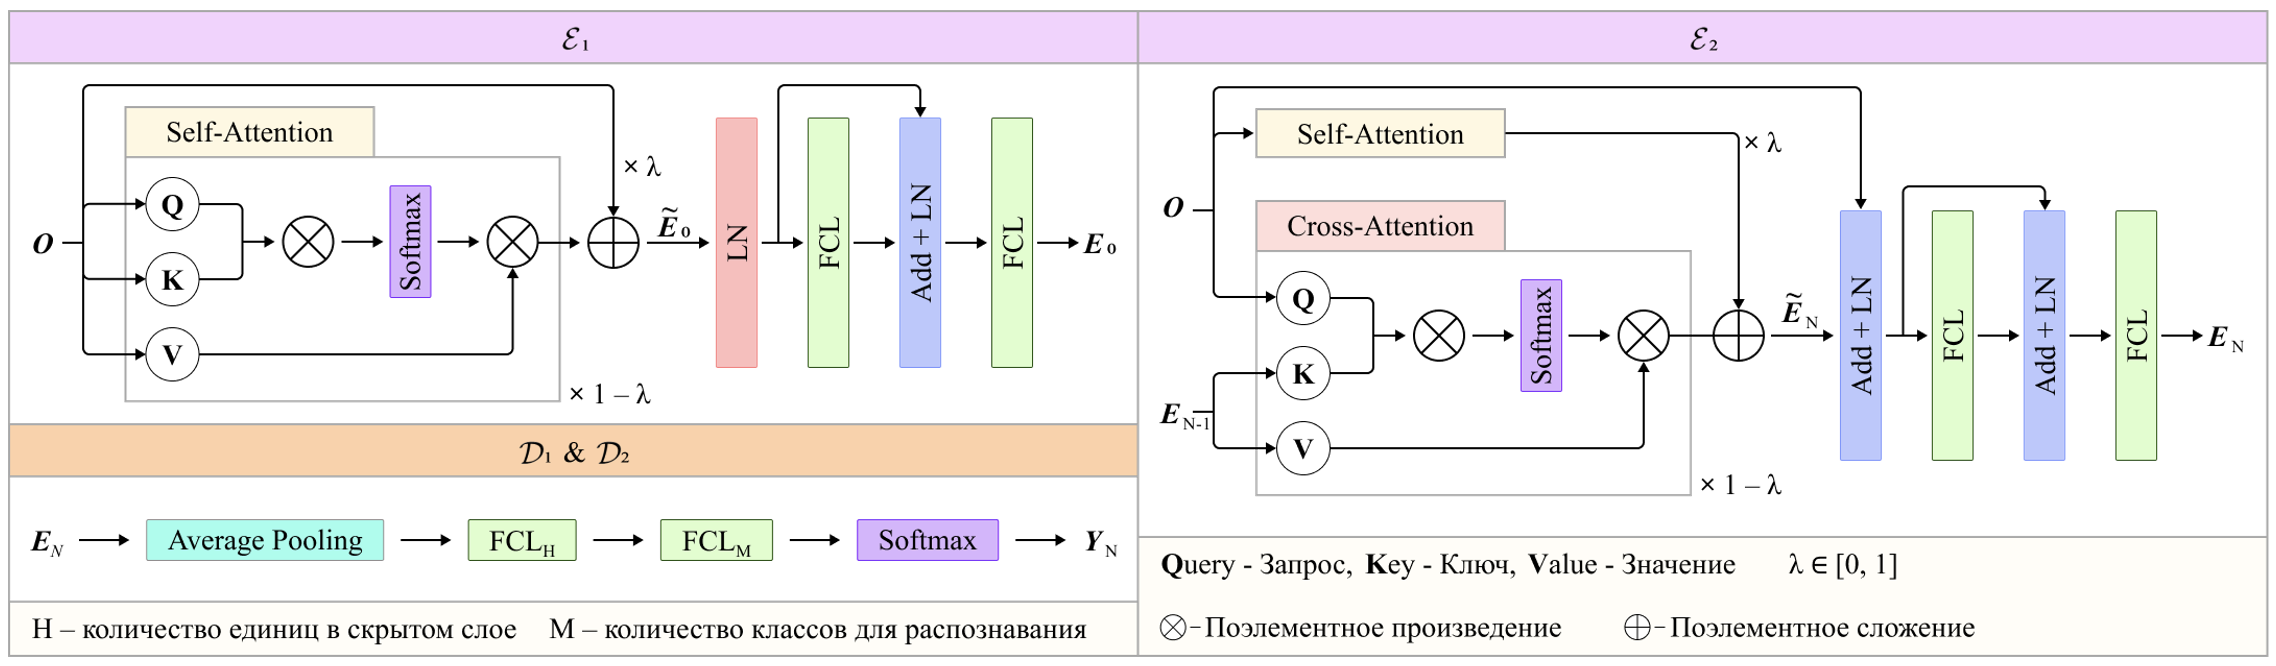

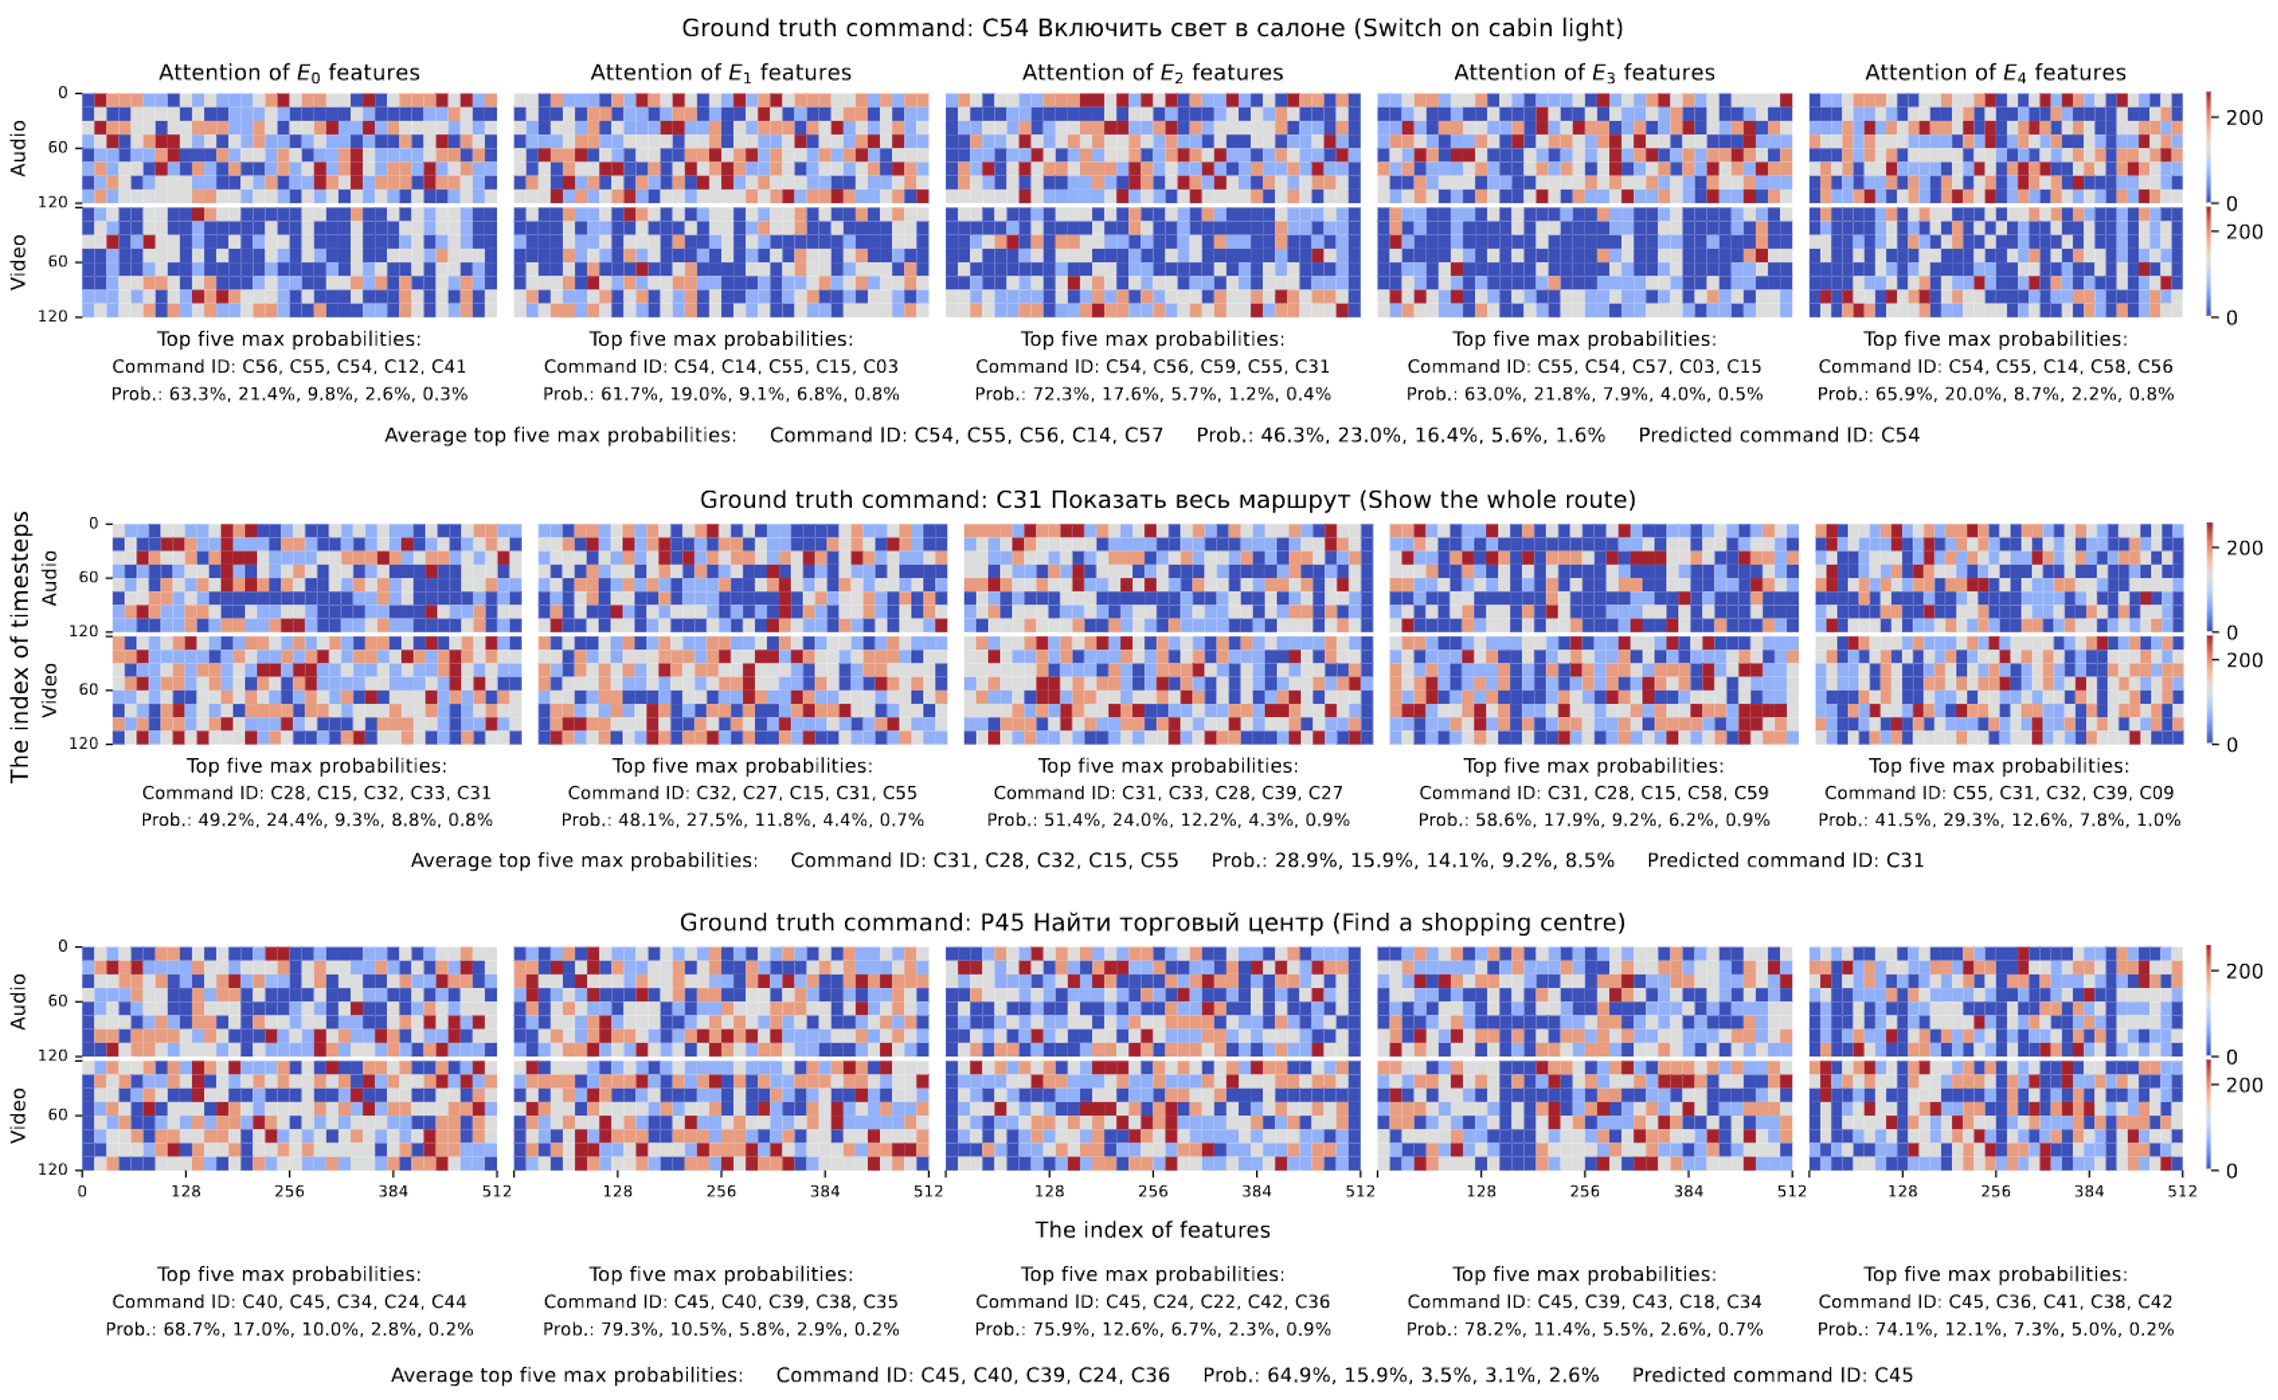

## Домашнее задание: Обучить нейросетевую модель на базе регулируемого трансформера (выбрать любую задачу и любые данные) и применить оптимизацию гиперпараметров с использованием методов Монте-Карло

#### Оценить и проанализировать результаты научных экспериментов

#### Сделать выводы